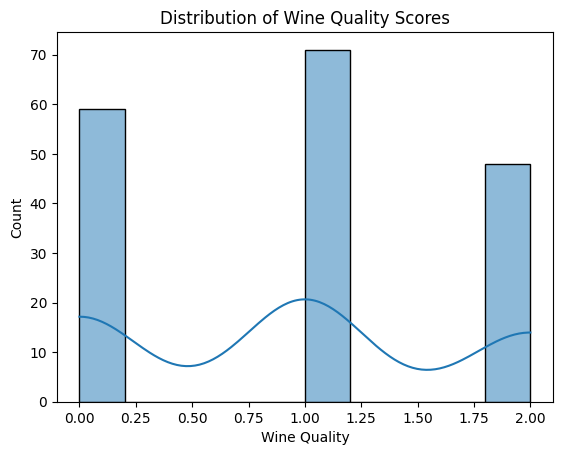

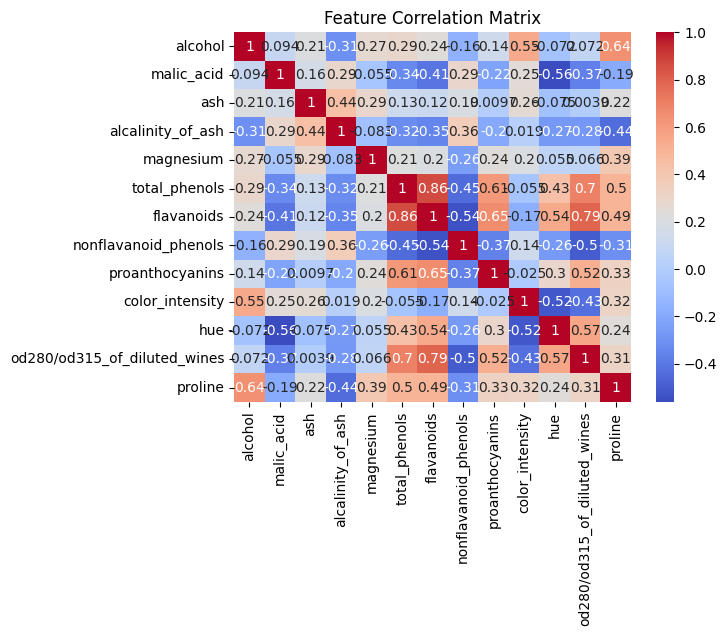

Mean Squared Error (NTK): 0.03917709116012811
Linear Regression MSE: 0.06853348464255991
Random Forest MSE: 0.06544722222222221


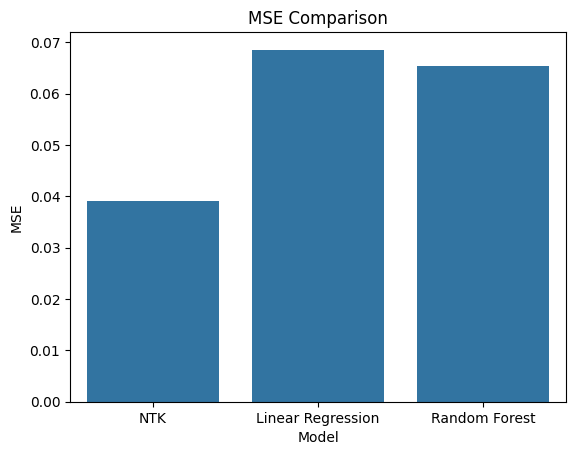

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
import torch
from numpy.linalg import solve

# Define the relu_ntk function
def relu_ntk(X, Z, depth=2, bias=0):
    from torch import acos
    pi = np.pi
    kappa_0 = lambda u: (1 - acos(u) / pi)
    kappa_1 = lambda u: u * kappa_0(u) + (1 - u.pow(2)).sqrt() / pi
    Z = Z if Z is not None else X
    eps = 0
    norm_x = X * X
    norm_x = torch.sqrt(torch.sum(norm_x, dim=1, keepdim=True))
    norm_z = Z * Z
    norm_z = torch.sqrt(torch.sum(norm_z, dim=1, keepdim=True).T)
    S = X @ Z.T

    N = S + bias ** 2

    for k in range(1, depth):
        in_ = (S / norm_x / norm_z).clip(-1 + eps, 1 - eps)
        S = norm_x * norm_z * kappa_1(in_)
        N = N * kappa_0(in_) + S + bias ** 2
    return N, S

# Define the ReLU_Kernel class
class ReLU_Kernel():

    def __init__(self, depth=2, bias=0, ntk=True):
        self.sol = None
        self.depth = depth
        self.X_train = None
        self.bias = bias
        self.ntk = ntk

    def fit(self, X, y, reg=0):
        self.X_train = torch.from_numpy(X).float()
        N, S = relu_ntk(self.X_train, self.X_train, bias=self.bias, depth=self.depth)
        if self.ntk:
            K = N.numpy()
        else:
            K = S.numpy()
        sol = solve(K + reg * np.eye(len(K)), y).T
        self.sol = sol
        return self

    def predict(self, X):
        X = torch.from_numpy(X).float()
        N, S = relu_ntk(self.X_train, X, depth=self.depth, bias=self.bias)
        if self.ntk:
            K = N.numpy()
        else:
            K = S.numpy()
        return (self.sol @ K).T

# Load the dataset
wine = load_wine()
X = wine.data
y = wine.target

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Visualize the distribution of wine quality
sns.histplot(y, kde=True, bins=10)
plt.xlabel('Wine Quality')
plt.ylabel('Count')
plt.title('Distribution of Wine Quality Scores')
plt.show()

# Correlation matrix
corr_matrix = pd.DataFrame(X, columns=wine.feature_names).corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Feature Correlation Matrix')
plt.show()

# Initialize the NTK model
ntk_model = ReLU_Kernel(depth=3, bias=0, ntk=True)

# Fit the model to training data
ntk_model.fit(X_train, y_train, reg=0.1)

# Make predictions on new data
y_pred_ntk = ntk_model.predict(X_test)

# Calculate the mean squared error for NTK model
mse_ntk = mean_squared_error(y_test, y_pred_ntk)
print(f'Mean Squared Error (NTK): {mse_ntk}')

# Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)
lr_mse = mean_squared_error(y_test, lr_pred)
print(f'Linear Regression MSE: {lr_mse}')

# Random Forest
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
rf_mse = mean_squared_error(y_test, rf_pred)
print(f'Random Forest MSE: {rf_mse}')

# Compare all MSEs
mse_comparison = pd.DataFrame({
    'Model': ['NTK', 'Linear Regression', 'Random Forest'],
    'MSE': [mse_ntk, lr_mse, rf_mse]
})

sns.barplot(x='Model', y='MSE', data=mse_comparison)
plt.title('MSE Comparison')
plt.show()
